# Source Video Matcher Walkthrough

Notebook-first workflow for one MIMIC exam: find the single-frame DICOMs that contain measurements, then preview the best parent-video candidates with the exact matcher scope.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path


def find_repo(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "app" / "tools" / "batch" / "headless_batch_label.py").is_file():
            return candidate
    raise RuntimeError("Open this notebook from the Master repo or a subdirectory inside it.")


REPO = find_repo(Path.cwd().resolve())
if str(REPO) not in sys.path:
    sys.path.insert(0, str(REPO))

EXAM_ROOT = Path("/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955")
EXAM_ROOT

PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955')

In [2]:
from app.io.dicom_loader import load_dicom_series

inventory = []
for path in sorted(EXAM_ROOT.glob("*.dcm")):
    series = load_dicom_series(path, load_pixels=False)
    inventory.append(
        {
            "path": path,
            "name": path.name,
            "frame_count": series.frame_count,
            "rows": series.metadata.rows,
            "cols": series.metadata.cols,
            "sop_uid": series.metadata.sop_instance_uid,
        }
    )

single_frame_candidates = [row for row in inventory if row["frame_count"] == 1]
video_candidates = [row for row in inventory if row["frame_count"] > 1]
print(f"single-frame candidates: {len(single_frame_candidates)}")
print(f"video candidates: {len(video_candidates)}")
single_frame_candidates[:5]

single-frame candidates: 35
video candidates: 54


[{'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0011.dcm'),
  'name': '94106955_0011.dcm',
  'frame_count': 1,
  'rows': 708,
  'cols': 1016,
  'sop_uid': '1.2.840.113554.6.1.101.335968620583297565691366701783674098723'},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0012.dcm'),
  'name': '94106955_0012.dcm',
  'frame_count': 1,
  'rows': 708,
  'cols': 1016,
  'sop_uid': '1.2.840.113554.6.1.101.770274716482656710590339665802387202387'},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0013.dcm'),
  'name': '94106955_0013.dcm',
  'frame_count': 1,
  'rows': 708,
  'cols': 1016,
  'sop_uid': '1.2.840.113554.6.1.101.946086558909381025167098589725714830568'},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0014.dcm'),
  'name': '94106955_0014.dcm',
  'frame_count': 1,
  'rows': 708,
  'cols': 1016,
  'sop_u

The matcher now compares only the center of the image: it moves **25% inward from each side** and uses the middle **50% x 50%** window. If the top-left measurement panel is detected, that panel is removed from the comparison scope.


In [4]:
from app.models.types import PipelineRequest
from app.pipeline.ai_pipeline import PipelineConfig
from app.pipeline.echo_ocr_pipeline import EchoOcrPipeline

engine = "glm-ocr"
fallback_engine = "glm-ocr"
pipeline = EchoOcrPipeline(
    config=PipelineConfig.with_parameters(
        {
            "ocr_engine": engine,
            "requested_ocr_engine": engine,
            "fallback_ocr_engine": fallback_engine,
            "strict_ocr_engine_selection": True,
            "max_frames": 1,
        }
    )
)
pipeline.ensure_components()

measurement_positive = []
for row in single_frame_candidates:
    result = pipeline.run(PipelineRequest(dicom_path=row["path"], parameters={"max_frames": 1}))
    if result.ai_result is None:
        continue
    raw = result.ai_result.raw if isinstance(result.ai_result.raw, dict) else {}
    line_predictions = raw.get("line_predictions", []) if isinstance(raw, dict) else []
    if result.ai_result.measurements or line_predictions:
        measurement_positive.append(
            {
                "path": row["path"],
                "name": row["name"],
                "measurement_count": len(result.ai_result.measurements),
                "line_prediction_count": len(line_predictions),
            }
        )

measurement_positive

The image processor of type `Glm46VImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


[{'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0011.dcm'),
  'name': '94106955_0011.dcm',
  'measurement_count': 1,
  'line_prediction_count': 1},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0012.dcm'),
  'name': '94106955_0012.dcm',
  'measurement_count': 1,
  'line_prediction_count': 1},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0013.dcm'),
  'name': '94106955_0013.dcm',
  'measurement_count': 1,
  'line_prediction_count': 1},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0014.dcm'),
  'name': '94106955_0014.dcm',
  'measurement_count': 1,
  'line_prediction_count': 1},
 {'path': PosixPath('/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0016.dcm'),
  'name': '94106955_0016.dcm',
  'measurement_count': 3,
  'line_prediction_count': 3},
 {'path': PosixPath('/run/medi

In [5]:
from app.io.video_source_matcher import (
    build_matcher_scope_for_measurement_dicom,
    find_source_video_for_measurement_dicom,
    rank_video_sources_for_measurement_dicom,
)

matches = []
for row in measurement_positive:
    best = find_source_video_for_measurement_dicom(row["path"], EXAM_ROOT)
    top3 = rank_video_sources_for_measurement_dicom(row["path"], EXAM_ROOT)[:3]
    scope = build_matcher_scope_for_measurement_dicom(row["path"], EXAM_ROOT)
    matches.append(
        {
            "measurement": row["name"],
            "path": row["path"],
            "best": best,
            "top3": top3,
            "scope": scope,
        }
    )

review_queue = sorted(matches, key=lambda item: float(item["top3"][0]["score"]) if item["top3"] else -1.0, reverse=True)
[(item["measurement"], item["best"]["score"], item["top3"][0]["dicomid"] if item["top3"] else None, item["top3"][0]["frame"] if item["top3"] else None) for item in review_queue[:10]]

[('94106955_0017.dcm',
  0.5833808779716492,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0009.dcm',
  15),
 ('94106955_0075.dcm',
  0.5821492075920105,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0070.dcm',
  39),
 ('94106955_0071.dcm',
  0.5802868008613586,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0070.dcm',
  69),
 ('94106955_0051.dcm',
  0.5545220375061035,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0049.dcm',
  41),
 ('94106955_0016.dcm',
  0.5415654182434082,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0009.dcm',
  48),
 ('94106955_0074.dcm',
  0.5283056497573853,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0070.dcm',
  56),
 ('94106955_0096.dcm',
  0.5251619815826416,
  '/run/media/warre/T7/MIMIC-IV-ECHO/files/p10/p10002221/s94106955/94106955_0093.dcm',
  29),
 ('94106955_0066.dcm',
  0.

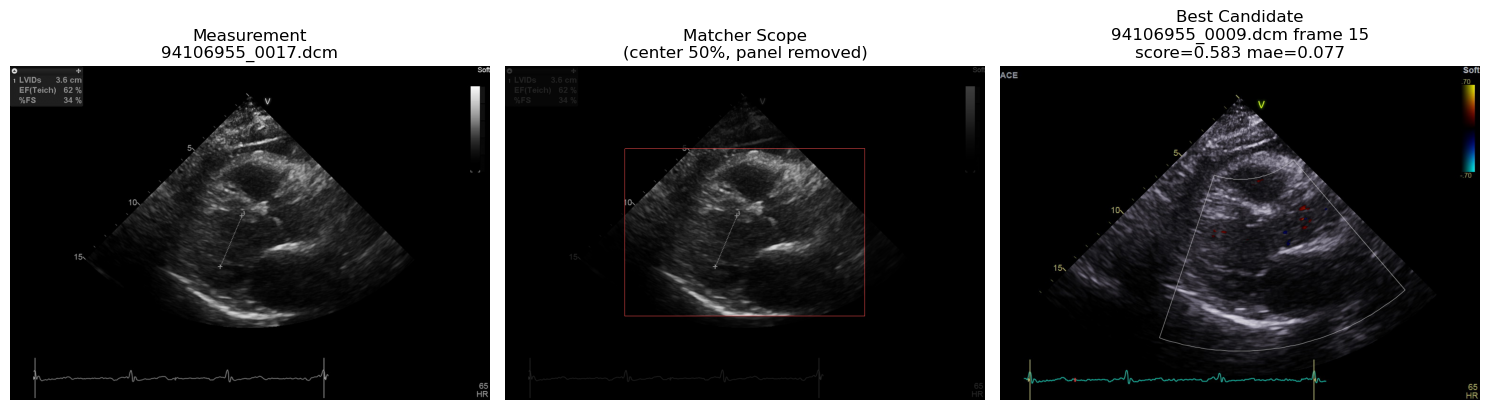

Top 3 candidates:
  1. 94106955_0009.dcm frame=15 score=0.583 mae=0.077
  2. 94106955_0008.dcm frame=42 score=0.579 mae=0.073
  3. 94106955_0007.dcm frame=72 score=0.506 mae=0.076



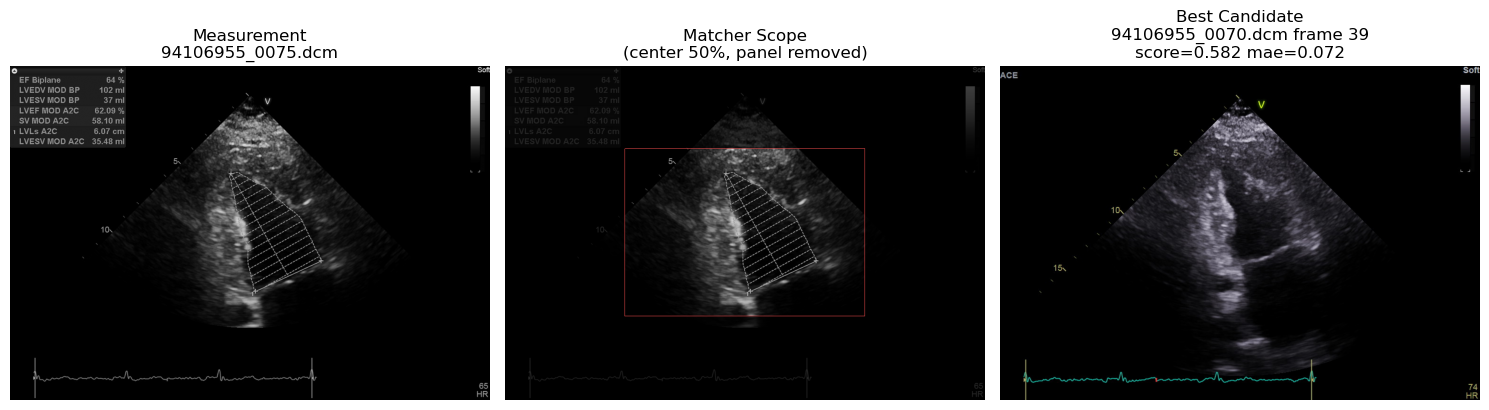

Top 3 candidates:
  1. 94106955_0070.dcm frame=39 score=0.582 mae=0.072
  2. 94106955_0072.dcm frame=68 score=0.528 mae=0.079
  3. 94106955_0073.dcm frame=67 score=0.490 mae=0.087



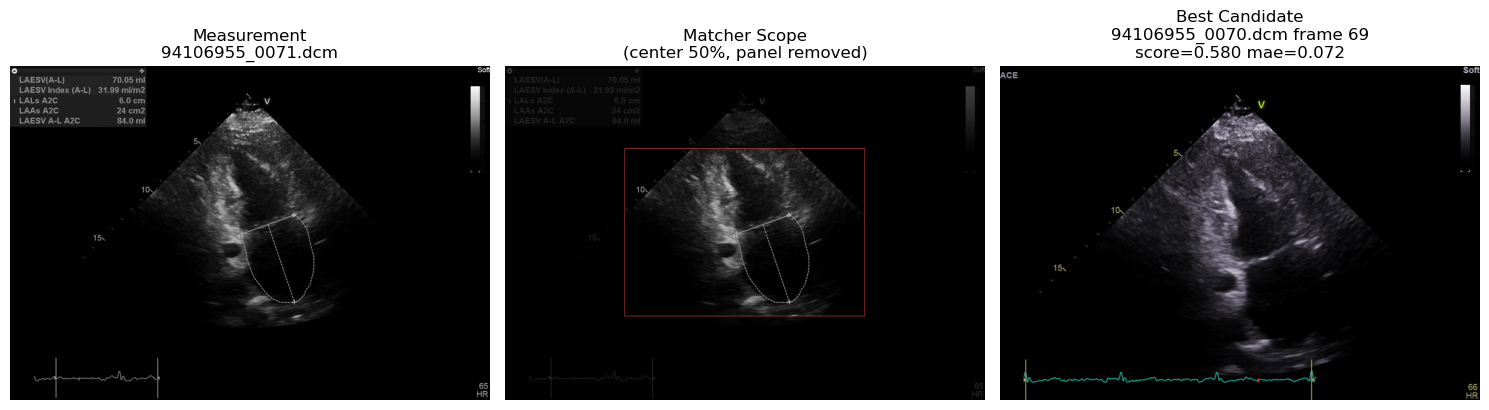

Top 3 candidates:
  1. 94106955_0070.dcm frame=69 score=0.580 mae=0.072
  2. 94106955_0072.dcm frame=72 score=0.557 mae=0.076
  3. 94106955_0093.dcm frame=13 score=0.503 mae=0.059



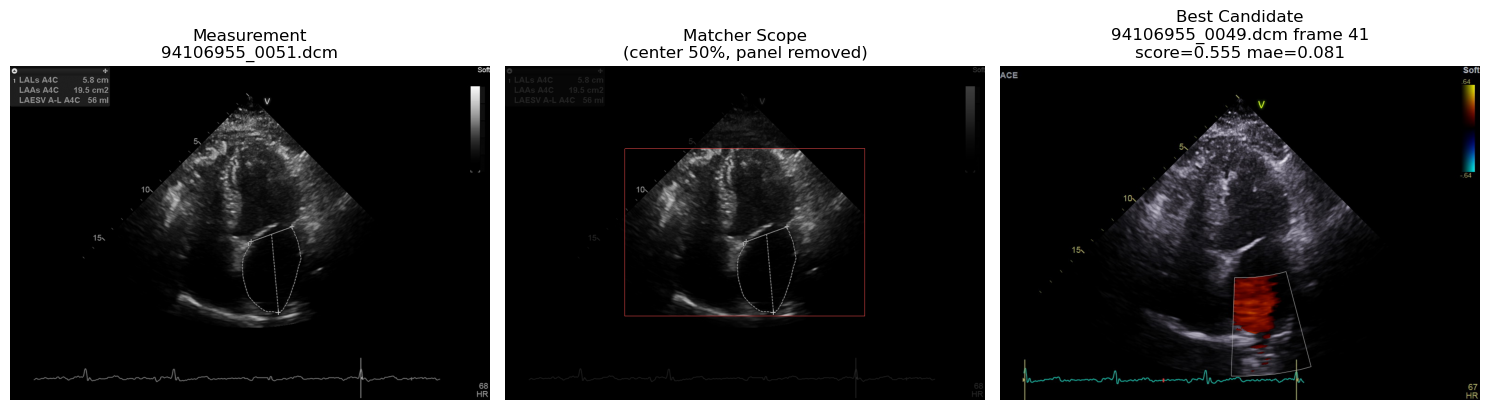

Top 3 candidates:
  1. 94106955_0049.dcm frame=41 score=0.555 mae=0.081
  2. 94106955_0047.dcm frame=14 score=0.417 mae=0.103
  3. 94106955_0058.dcm frame=40 score=0.416 mae=0.104



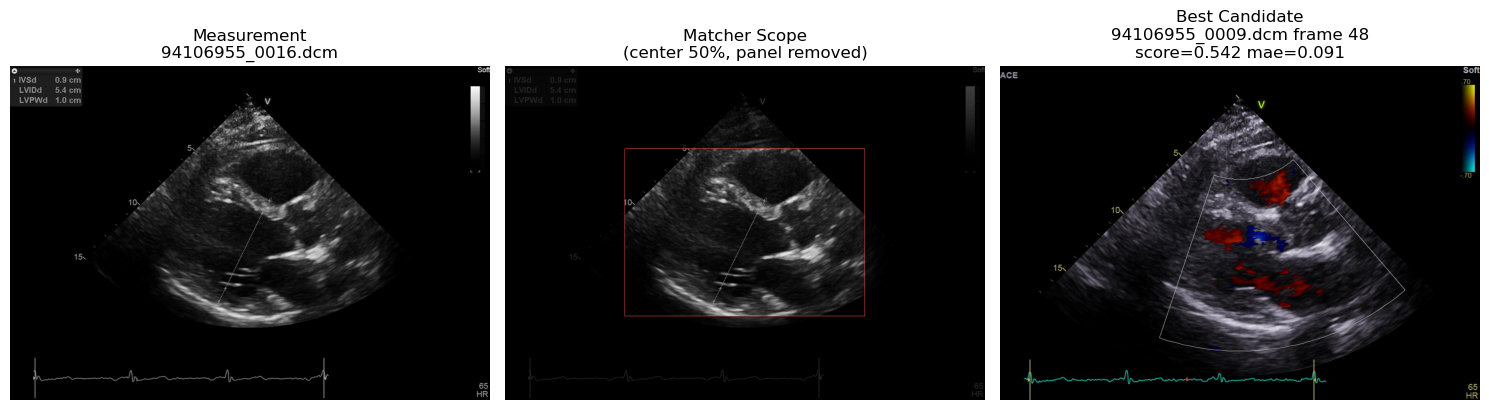

Top 3 candidates:
  1. 94106955_0009.dcm frame=48 score=0.542 mae=0.091
  2. 94106955_0008.dcm frame=25 score=0.539 mae=0.086
  3. 94106955_0007.dcm frame=55 score=0.428 mae=0.089



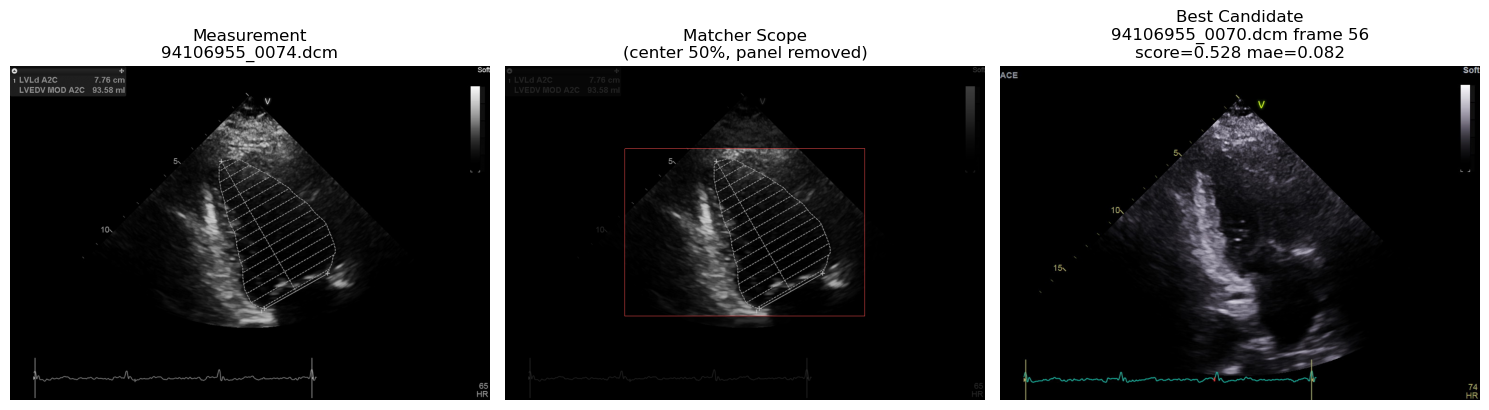

Top 3 candidates:
  1. 94106955_0070.dcm frame=56 score=0.528 mae=0.082
  2. 94106955_0073.dcm frame=73 score=0.509 mae=0.087
  3. 94106955_0032.dcm frame=43 score=0.480 mae=0.082



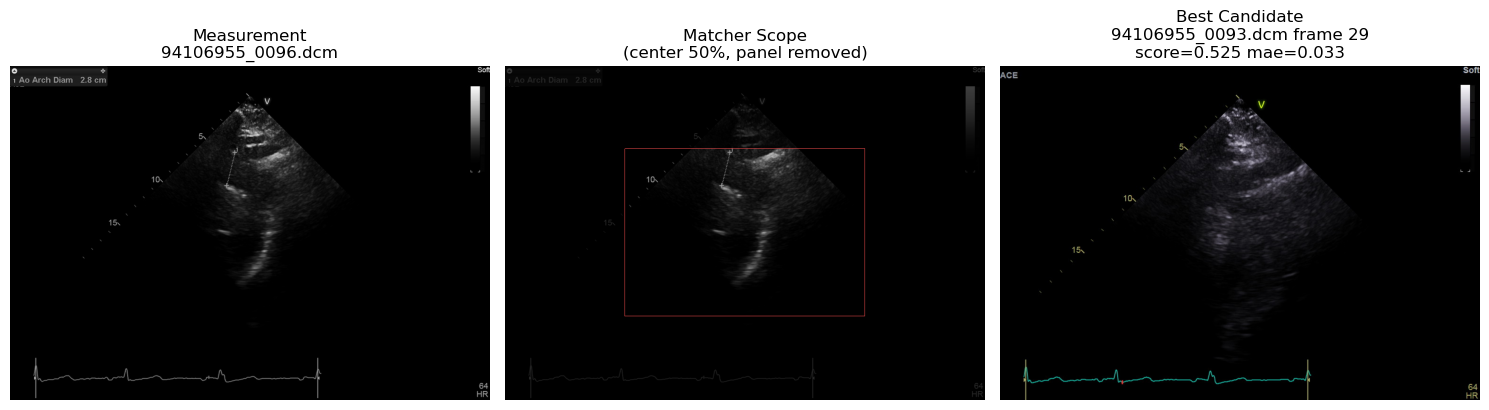

Top 3 candidates:
  1. 94106955_0093.dcm frame=29 score=0.525 mae=0.033
  2. 94106955_0094.dcm frame=7 score=0.476 mae=0.045
  3. 94106955_0082.dcm frame=72 score=0.423 mae=0.101



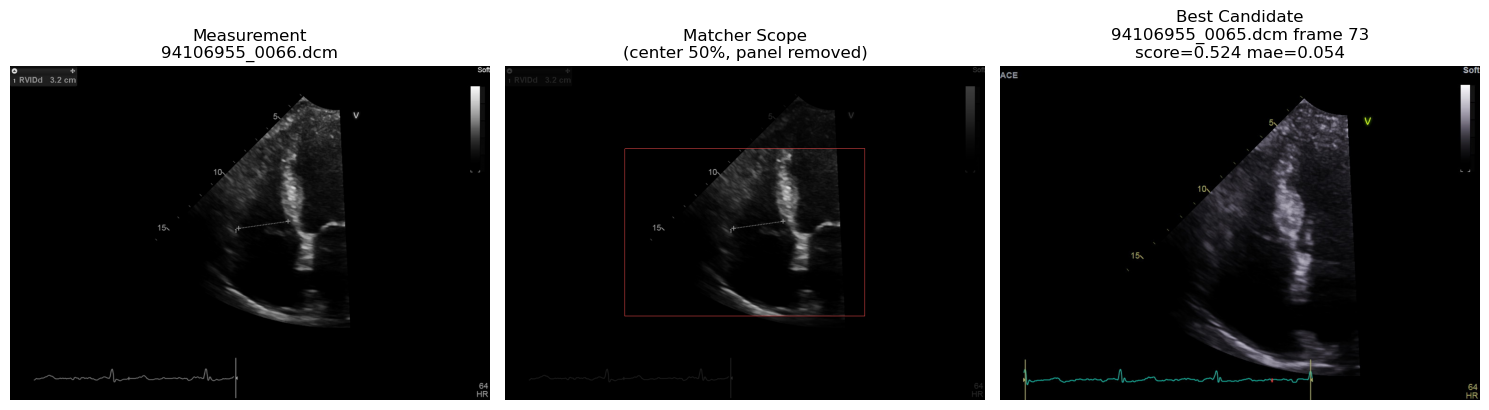

Top 3 candidates:
  1. 94106955_0065.dcm frame=73 score=0.524 mae=0.054
  2. 94106955_0059.dcm frame=11 score=0.393 mae=0.113
  3. 94106955_0063.dcm frame=16 score=0.376 mae=0.111



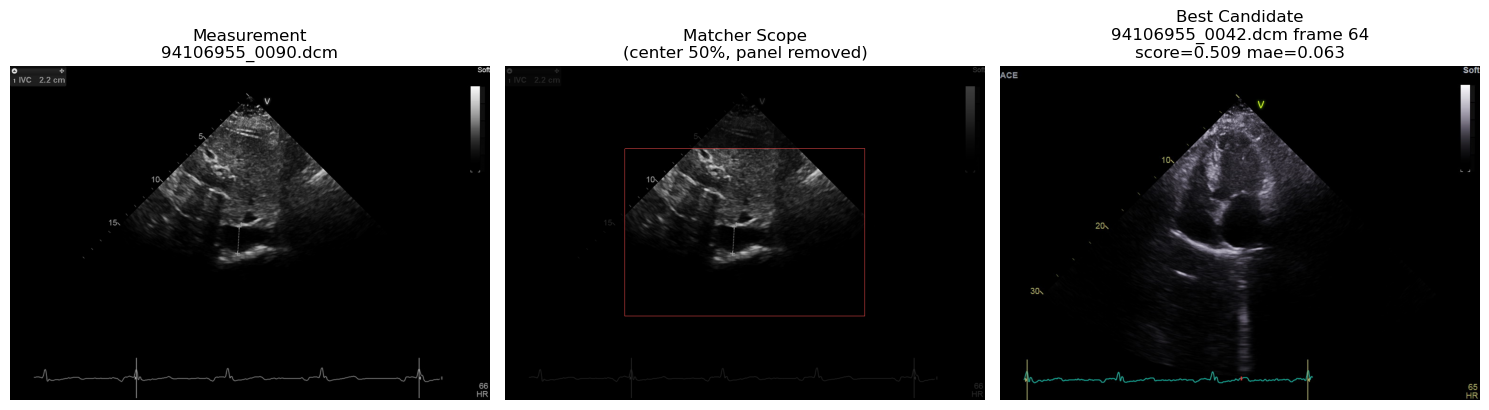

Top 3 candidates:
  1. 94106955_0042.dcm frame=64 score=0.509 mae=0.063
  2. 94106955_0081.dcm frame=51 score=0.500 mae=0.088
  3. 94106955_0080.dcm frame=66 score=0.493 mae=0.092



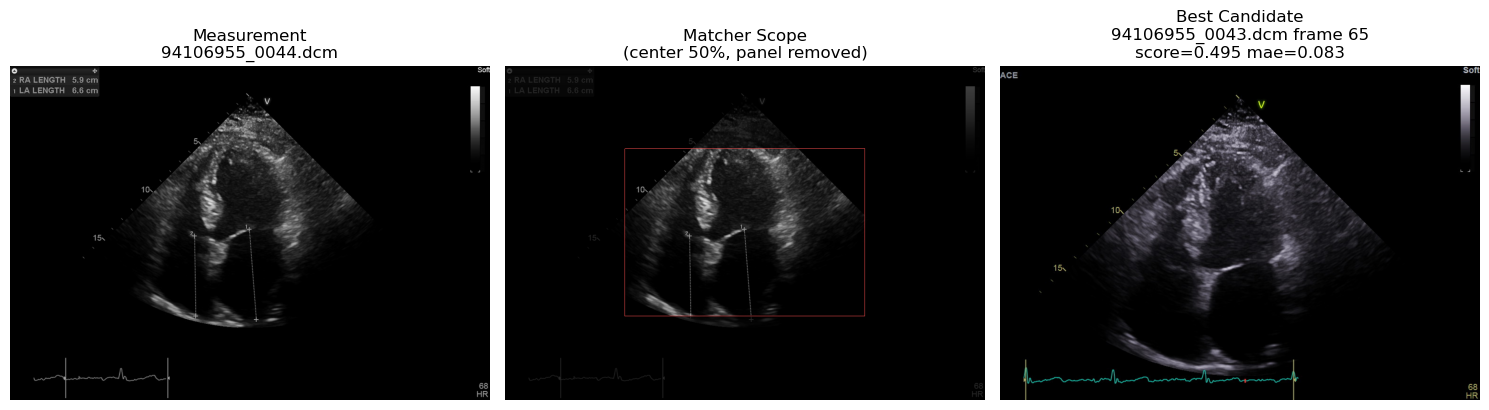

Top 3 candidates:
  1. 94106955_0043.dcm frame=65 score=0.495 mae=0.083
  2. 94106955_0067.dcm frame=69 score=0.460 mae=0.089
  3. 94106955_0060.dcm frame=49 score=0.458 mae=0.087



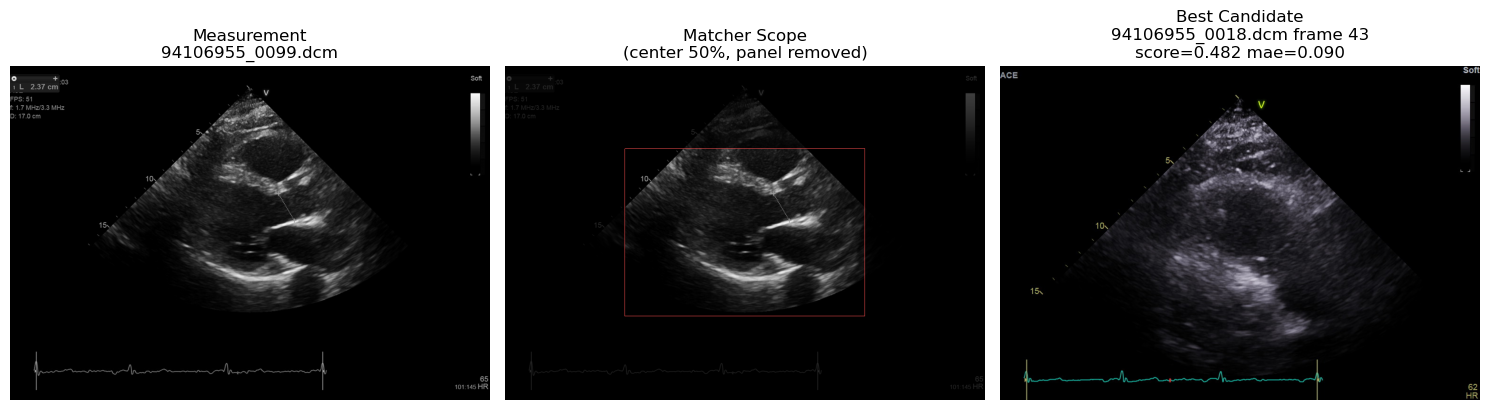

Top 3 candidates:
  1. 94106955_0018.dcm frame=43 score=0.482 mae=0.090
  2. 94106955_0020.dcm frame=44 score=0.451 mae=0.096
  3. 94106955_0019.dcm frame=73 score=0.441 mae=0.100



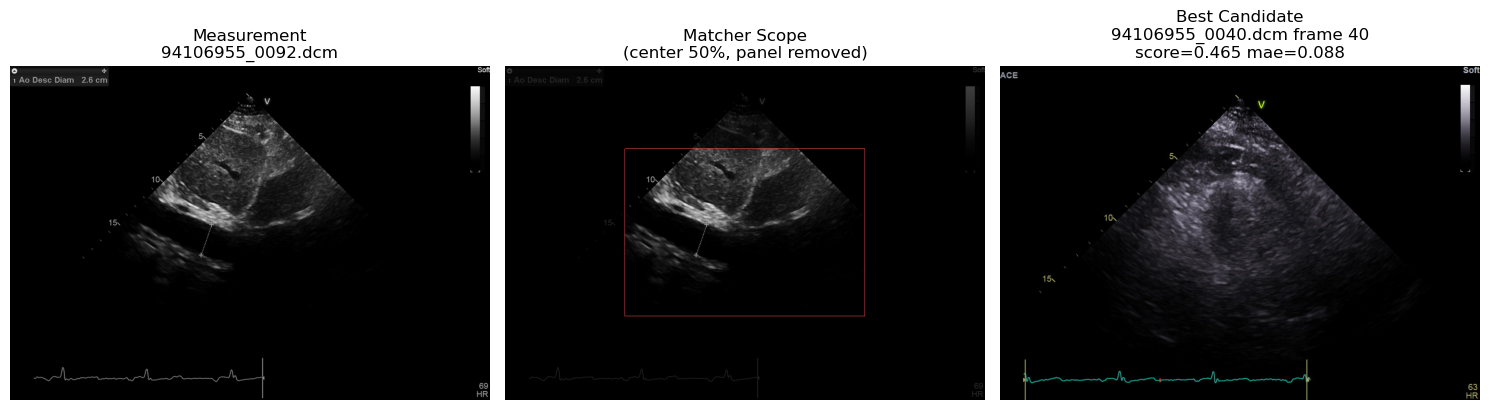

Top 3 candidates:
  1. 94106955_0040.dcm frame=40 score=0.465 mae=0.088
  2. 94106955_0088.dcm frame=83 score=0.453 mae=0.098
  3. 94106955_0079.dcm frame=20 score=0.427 mae=0.090



In [6]:
import matplotlib.pyplot as plt
import numpy as np

from app.io.dicom_loader import load_dicom_series


def overlay_scope(frame: np.ndarray, mask: np.ndarray) -> np.ndarray:
    base = frame.astype(np.float32)
    if base.ndim == 2:
        base = np.stack([base, base, base], axis=-1)
    out = base.copy()
    out[~mask] *= 0.25
    border = np.zeros(mask.shape, dtype=bool)
    border[:-1, :] |= mask[:-1, :] != mask[1:, :]
    border[:, :-1] |= mask[:, :-1] != mask[:, 1:]
    out[border] = np.array([255.0, 80.0, 80.0], dtype=np.float32)
    return np.clip(out, 0, 255).astype(np.uint8)


top_n = 12
for item in review_queue[:top_n]:
    if not item["top3"]:
        continue
    best = item["top3"][0]
    candidate_path = Path(best["dicomid"])
    candidate_series = load_dicom_series(candidate_path, load_pixels=False)
    candidate_frame = candidate_series.get_frame(int(best["frame"]))
    scope = item["scope"]

    measurement_frame = scope["frame"]
    measurement_mask = scope["mask"]
    scoped_preview = overlay_scope(measurement_frame, measurement_mask)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(measurement_frame, cmap="gray")
    axes[0].set_title(f"Measurement\n{item['measurement']}")
    axes[1].imshow(scoped_preview)
    axes[1].set_title("Matcher Scope\n(center 50%, panel removed)")
    axes[2].imshow(candidate_frame, cmap="gray")
    axes[2].set_title(
        f"Best Candidate\n{candidate_path.name} frame {best['frame']}\nscore={best['score']:.3f} mae={best['mae']:.3f}"
    )
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

    print("Top 3 candidates:")
    for rank, candidate in enumerate(item["top3"], start=1):
        print(
            f"  {rank}. {Path(candidate['dicomid']).name} frame={candidate['frame']} score={candidate['score']:.3f} mae={candidate['mae']:.3f}"
        )
    print()
